# V3 moneyness performance — 1.5-year monthly study

**This notebook is the computational source of truth.** The matching PDF is written from the same payload.

This report classifies the **same** option contracts as `V3_1p5y_monthly_empirical_study` into DOTM / OTM / ATM / ITM / DITM. It does not change filters, calibration, contracts, LSM settings, or the market benchmark.

| Item | Setting |
|------|---------|
| Models | GBM, GARCH, Heston, Merton, GARCH–Merton, Heston–Merton |
| Companies | SPY, AAPL, MSFT (pooled in both analyses) |
| Regimes | Crisis, Normal, Late-cycle, COVID (pooled in Analysis 1; separate in Analysis 2) |
| Contracts | Monday nearest-ATM listed calls from the main study (`n = 601` per model) |
| Moneyness | `m = S/K` (calls) |
| Primary metric | RMSE% |
| Secondary | MAE, Bias $, **Bias%**, Early-exercise fraction |


## 0. Methodology

### Same design as the main study
1.5-year lookback, monthly recalibration, V3 filters (no-arbitrage, DTE 7–60, |S/K−1|≤10%, liquidity), Euler-corrected Heston, option-implied Heston NLS, LSM with 2,000 paths and seed 42. No look-ahead.

### Moneyness rule (calls)
Let `m = S/K`.

| Bucket | Rule |
|--------|------|
| DOTM | m < 0.98 |
| OTM | 0.98 ≤ m < 0.995 |
| ATM | 0.995 ≤ m ≤ 1.005 |
| ITM | 1.005 < m ≤ 1.02 |
| DITM | m > 1.02 |

These five bins partition the main-study 10% moneyness filter. The Monday ATM sampler concentrates mass in ATM.

### Metrics
- RMSE% = 100 × √ mean(((model − market)/market)²)
- Bias $ = mean(model − market)
- Bias% = 100 × mean((model − market)/market)
- BEST = lowest RMSE% among models with n > 0


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1p5y_10k_monthly_moneyness_study as mx
panel = mx.load_panel()
payload = mx.build_payload(panel)
pdf = mx.write_pdf(payload)
print('n_overall', payload['n_overall'])
print('PDF', pdf)

## 1. Shared sample counts


In [1]:
display(HTML('counts'))

Regime,DOTM,OTM,ATM,ITM,DITM,Total
2008-2009,8,30,72,34,6,150
2013-2014,0,5,142,3,0,150
2018-2019,0,4,140,7,0,151
2019-2020,0,6,139,5,0,150
All,8,45,493,49,6,601


## 2. Analysis 1 — Overall moneyness


### Table M1. DOTM  ·  m < 0.98  ·  n = 8  ·  **BEST = Heston–Merton**


In [1]:
tab = payload['analysis1']['DOTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,8,38.99,1.0687,+0.1518,+18.27,17.4%,5
GARCH,8,38.88,1.0352,+1.0352,+32.13,16.4%,4
Heston,8,27.37,0.8354,+0.8354,+21.90,20.4%,2
Merton,8,35.89,0.9641,+0.0252,+15.01,15.3%,3
GARCH–Merton,8,49.69,1.4663,+1.4663,+43.21,13.6%,6
Heston–Merton,8,26.73,0.8325,+0.8325,+21.13,16.0%,1


### Table M2. OTM  ·  0.98 ≤ m < 0.995  ·  n = 45  ·  **BEST = Heston–Merton**


In [1]:
tab = payload['analysis1']['OTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,45,65.05,1.7303,+0.8262,+34.72,21.6%,4
GARCH,45,72.45,1.9400,+1.6133,+49.67,24.7%,5
Heston,45,37.34,1.1727,+0.7013,+23.09,20.2%,2
Merton,45,63.01,1.7017,+0.7294,+32.09,16.9%,3
GARCH–Merton,45,82.67,2.1269,+1.8807,+62.00,23.1%,6
Heston–Merton,45,36.89,1.1665,+0.5824,+20.12,15.4%,1


### Table M3. ATM  ·  0.995 ≤ m ≤ 1.005  ·  n = 493  ·  **BEST = Merton**


In [1]:
tab = payload['analysis1']['ATM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,493,49.51,2.0094,+1.2989,+32.17,24.0%,4
GARCH,493,57.86,2.1491,+1.8497,+39.76,23.4%,5
Heston,493,47.58,1.9916,+1.6436,+34.64,23.6%,2
Merton,493,46.46,1.8715,+1.1231,+28.85,19.5%,1
GARCH–Merton,493,128.41,3.0863,+2.8985,+56.65,22.0%,6
Heston–Merton,493,49.36,1.8674,+1.4954,+32.85,17.5%,3


### Table M4. ITM  ·  1.005 < m ≤ 1.02  ·  n = 49  ·  **BEST = Heston–Merton**


In [1]:
tab = payload['analysis1']['ITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,49,39.08,1.3788,+0.6083,+16.37,26.8%,4
GARCH,49,57.82,1.6448,+1.5143,+44.04,29.2%,5
Heston,49,30.59,1.2225,+0.7848,+15.66,26.6%,2
Merton,49,36.85,1.3139,+0.4977,+13.73,20.8%,3
GARCH–Merton,49,65.95,1.9885,+1.9081,+54.61,26.5%,6
Heston–Merton,49,29.95,1.1187,+0.6541,+14.47,19.4%,1


### Table M5. DITM  ·  m > 1.02  ·  n = 6  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['DITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,6,37.81,0.8669,-0.2089,+16.37,28.7%,3
GARCH,6,65.46,1.9584,+1.9584,+55.63,30.4%,5
Heston,6,16.09,0.3200,+0.2097,+8.73,27.5%,1
Merton,6,38.51,0.9122,-0.3251,+14.50,23.0%,4
GARCH–Merton,6,77.72,2.2914,+2.2914,+67.88,22.4%,6
Heston–Merton,6,17.29,0.3896,+0.1808,+8.83,20.1%,2


### Figure M1 — Model × Moneyness RMSE% heatmap


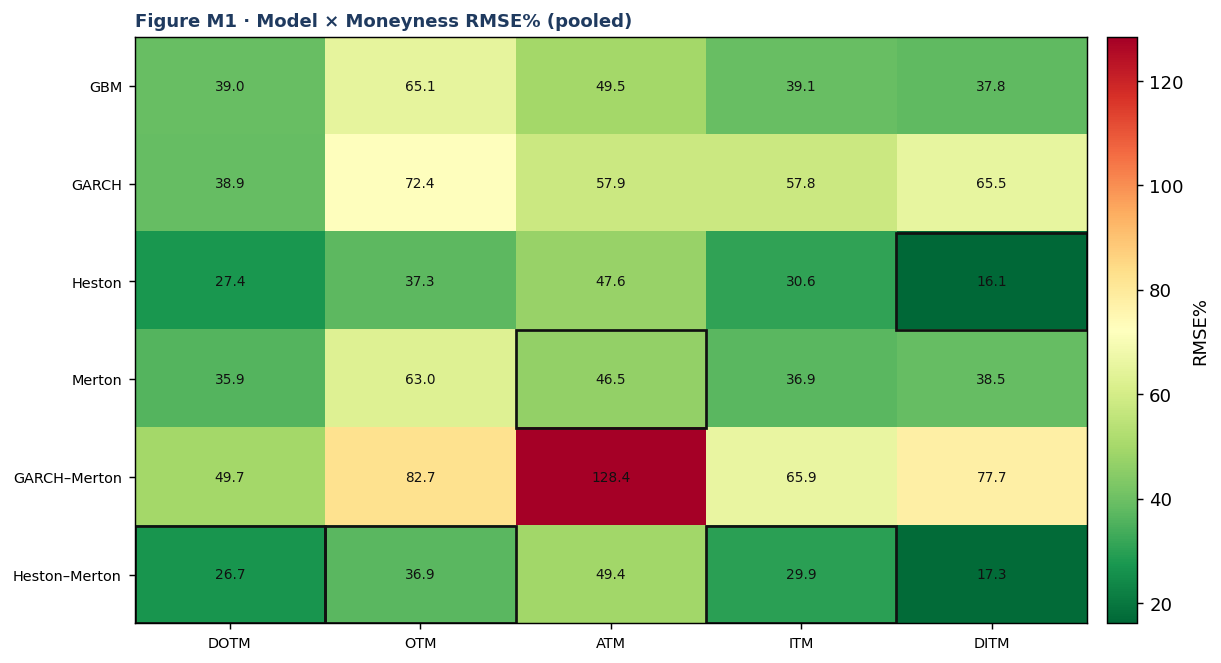

In [1]:
pass

## 3. Analysis 2 — Regime × moneyness


### Figure M2 — RMSE% heatmaps by regime


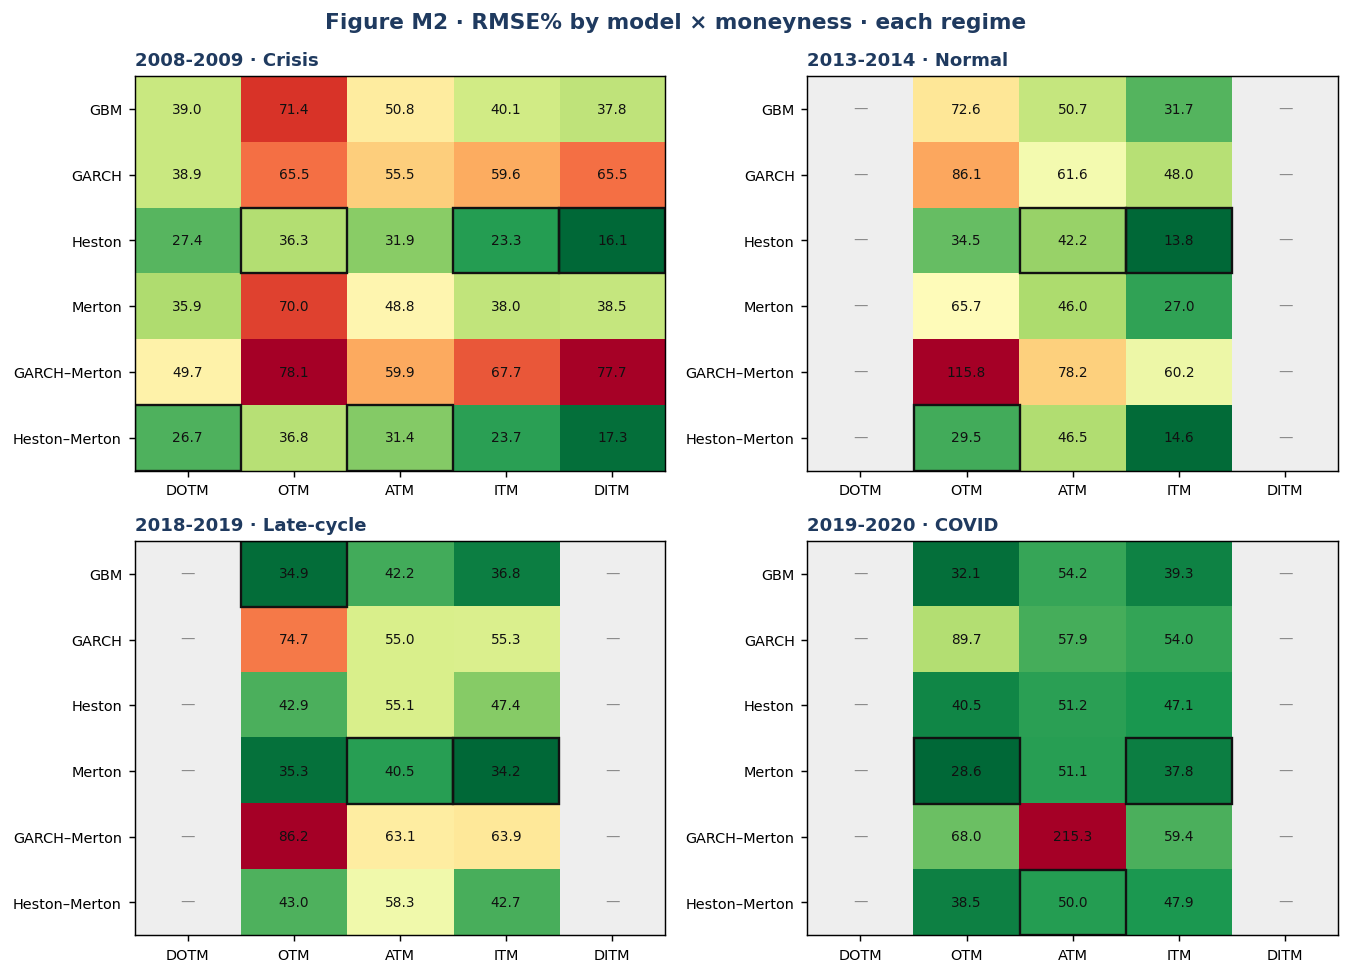

In [1]:
pass

### Table M6 — Best model by regime × moneyness


In [1]:
display(HTML('m6'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,Heston–Merton,Heston,Heston–Merton,Heston,Heston
2013-2014,—,Heston–Merton,Heston,Heston,—
2018-2019,—,GBM,Merton,Merton,—
2019-2020,—,Merton,Heston–Merton,Merton,—


### Table M7 — n by regime × moneyness


In [1]:
display(HTML('m7'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,8,30,72,34,6
2013-2014,0,5,142,3,0
2018-2019,0,4,140,7,0
2019-2020,0,6,139,5,0


## 4. Findings

- DOTM (n = 8): BEST = Heston–Merton with RMSE% = 26.73, Bias% = +21.13.

- OTM (n = 45): BEST = Heston–Merton with RMSE% = 36.89, Bias% = +20.12.

- ATM (n = 493): BEST = Merton with RMSE% = 46.46, Bias% = +28.85.

- ITM (n = 49): BEST = Heston–Merton with RMSE% = 29.95, Bias% = +14.47.

- DITM (n = 6): BEST = Heston with RMSE% = 16.09, Bias% = +8.73.

- Overall, the ranking does change with moneyness: DOTM → Heston–Merton, OTM → Heston–Merton, ATM → Merton, ITM → Heston–Merton, DITM → Heston.

- Inside regimes, the BEST model also changes with moneyness in: 2008-2009, 2013-2014, 2018-2019, 2019-2020.

- These comparisons use the Monday nearest-ATM sample, so ATM is the only well-populated bucket after 2009. DOTM/DITM results rest on few 2008–2009 quotes and should be read as descriptive, not as a high-powered test.


## 5. Re-run

```python
import run_v3_1p5y_10k_monthly_moneyness_study as mx
payload = mx.run()
```

Requires the main study contract CSVs under `V3-Models_result/results/empirical_study_1p5y_monthly_10000/contracts/`.
